# Round 2: K-Means Analysis
**Goal**: Unsupervised clustering on mBERT embeddings to check class separability.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
from transformers import BertTokenizer, BertModel
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import json

sns.set(style='whitegrid')
reports_dir = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/reports'
os.makedirs(reports_dir, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [14]:
# Load Concatenated Train/Val Data
df_train = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/train.xlsx')
df_val = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/val.xlsx')
df = pd.concat([df_train, df_val], ignore_index=True)
df['cleaned_poem'] = df['cleaned_poem'].astype(str)
print(f"Loaded {len(df)} poems.")

Loaded 4124 poems.


In [15]:
print("Loading mBERT...")
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertModel.from_pretrained('bert-base-multilingual-cased').to(device)
model.eval()

Loading mBERT...


/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [16]:
def get_embeddings(texts, batch_size=32):
    embeddings = []
    total = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size].tolist()
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
        if (i+batch_size) % 500 == 0: print(f"Processed {i+batch_size}/{total}")
    return np.vstack(embeddings)

X_emb = get_embeddings(df['cleaned_poem'])

Processed 4000/4124


In [17]:
k = 9
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_emb)
df['cluster'] = clusters
sil = silhouette_score(X_emb, clusters)
print(f"Silhouette Score: {sil:.4f}")

Silhouette Score: 0.2708


t-SNE Reduction...


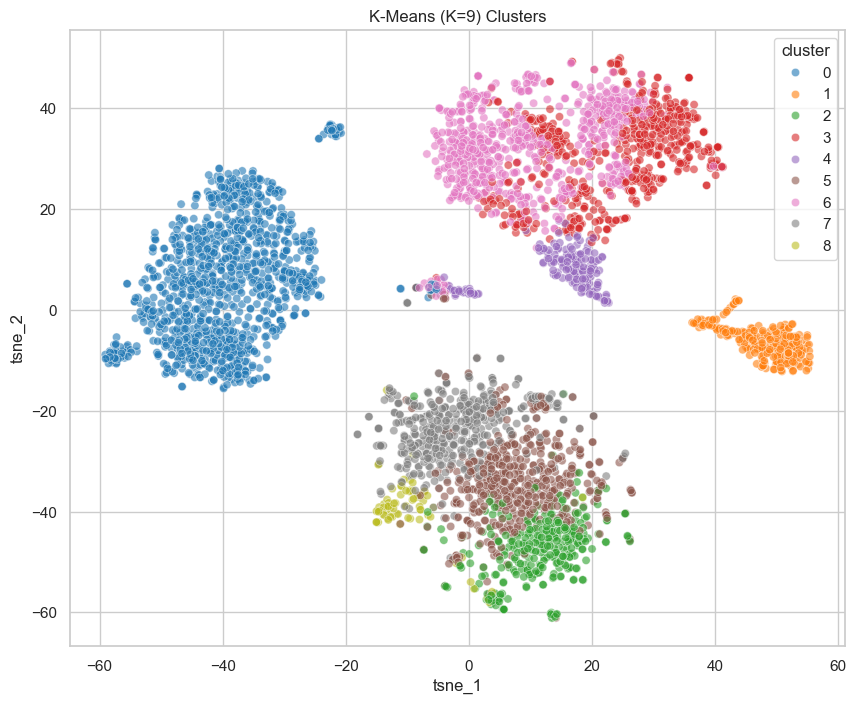

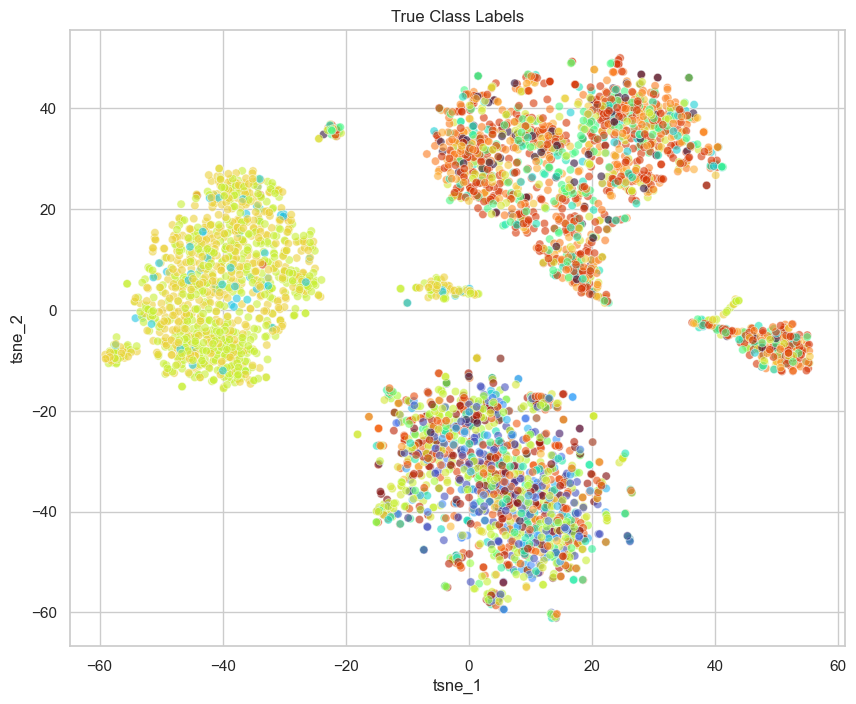

In [18]:
print("t-SNE Reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto', n_jobs=1)
X_tsne = tsne.fit_transform(X_emb)
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='cluster', data=df, palette='tab10', alpha=0.6)
plt.title(f'K-Means (K={k}) Clusters')
plt.savefig(f'{reports_dir}/kmeans_clusters.png')
plt.show()

plt.figure(figsize=(10, 8))
# Use primary_emotion column if exists (train.xlsx has ids, maybe logic to map back or just use id)
# Checking columns... train.xlsx usually has 'primary_id' and 'primary_emotion' if we kept it.
# Let's assume 'primary_id' exists and color by that for now.
hue_col = 'primary_id' if 'primary_id' in df.columns else 'cluster'
sns.scatterplot(x='tsne_1', y='tsne_2', hue=hue_col, data=df, palette='turbo', alpha=0.6, legend=False)
plt.title('True Class Labels')
plt.savefig(f'{reports_dir}/true_labels_tsne.png')
plt.show()